Figure 1 Draft

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

In [2]:
CARIACO = pd.read_csv("../DATA/processed/CARIACO_EnvData_combined.csv")

In [3]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling', 'euphotic_depth'],
      dtype='object')

In [15]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [5]:
Fish = pd.read_csv("../DATA/processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [6]:

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean
import datetime

# --- Helper Function 1: Geometric Mean Calculation ---

def safe_gmean(series):
    """Calculates geometric mean, ignoring NaNs and non-positive values."""
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# --- Helper Function 2: Data Processing (Resampling and Clustering) ---

def process_data_for_timelines(CARIACO_raw, Fish_raw):
    """
    Cleans, resamples, calculates G-Means, and sets up dates for plotting.
    """
    
    # 1. Process Data
    CARIACO_raw['date'] = pd.to_datetime(CARIACO_raw.time_month, format="%m-%Y")
    Fish_raw['date'] = pd.to_datetime(Fish_raw.year, format="%Y")
    CARIACO_raw['Zoo_Total'] = CARIACO_raw['Mesh200'] + CARIACO_raw['Mesh500']
    Fish_raw['sardinelandings_M'] = Fish_raw['sardinelandings'] / 1_000_000

    # 2. Calculate Yearly Geometric Means
    yearly_cariaco = CARIACO_raw.resample('YE', on='date').agg({
        'Isotherm_21': safe_gmean,
        'Chlorophyll': safe_gmean,
        'Zoo_Total': safe_gmean
    }).reset_index()

    # Create 'plot_date' at the middle of the year (July 1st)
    yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)
    Fish_raw['plot_date'] = Fish_raw['date'] + pd.DateOffset(months=6)
    
    # 3. Define and Assign Clusters (Needed for background shading)
    c1_ranges = [
        (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
        (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
    ]
    c2_ranges = [
        (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
    ]
    
    # We only need the ranges here, not the full DF assignment, but keeping them
    # defined for the shading logic below.
    
    return yearly_cariaco, Fish_raw, c1_ranges, c2_ranges

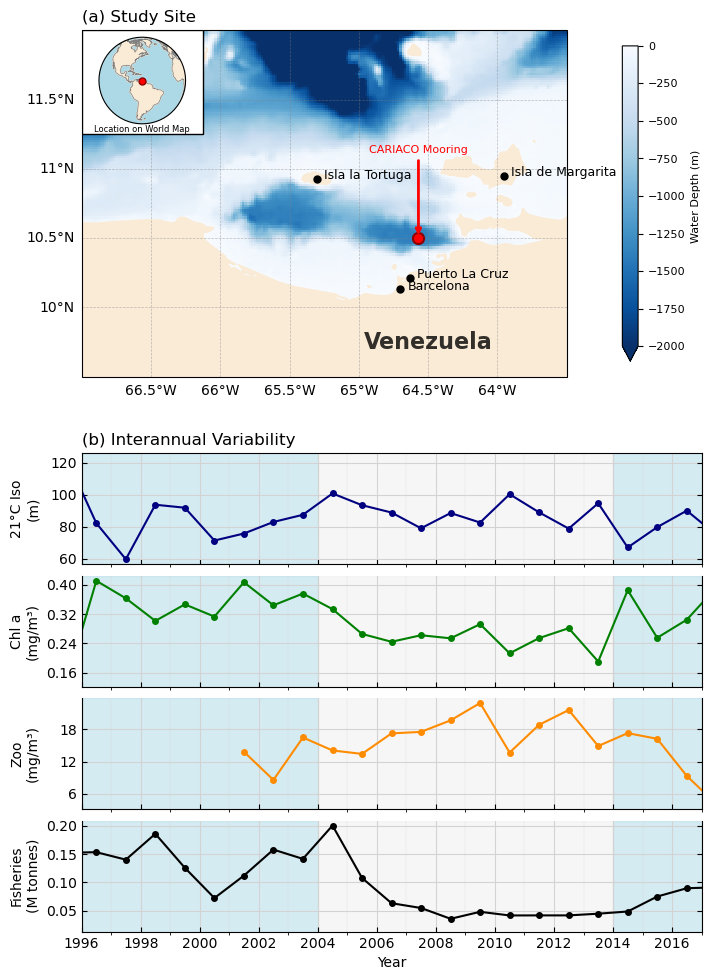

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np
import pygmt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import datetime
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# --- Fixed Parameters for Map ---
lon_min, lon_max = -67.0, -63.5
lat_min, lat_max = 9.5, 12.0
region = [lon_min, lon_max, lat_min, lat_max] 
mooring_lon = -64.57
mooring_lat = 10.5

# --- Load bathymetry data ---
def load_bathymetry(region):
    """Loads bathymetry data using PyGMT."""
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region)
    grid = pygmt.grdclip(grid, above=[0, 0]) # Clip land elevations to 0
    return grid

# --- Draw map function ---
def draw_cariaco_map_with_inset(ax, fig, grid):
    """
    Draws the full Cariaco Basin map, including inset and colorbar, onto 
    a provided Cartopy axis (ax) and figure (fig).
    """
    # --- Fixed Colormap ---
    cmap = plt.get_cmap("Blues_r")
    norm = mcolors.Normalize(vmin=-2000, vmax=0)

    # 1. Setup Main Map
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- Plot PyGMT Grid using Cartopy/Xarray ---
    grid.plot.pcolormesh(
        ax=ax,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        zorder=0,
        add_colorbar=False
    )

    # --- Cartopy Styling ---
    # Add land feature
    ax.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    
    # Add gridlines with labels - CHANGED TO SIZE 10
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                      alpha=0.5, linestyle='--', zorder=3)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}  # Changed from 11 to 10
    gl.ylabel_style = {'size': 10}  # Changed from 11 to 10
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Add cities and islands
    cities = {'Puerto La Cruz': (-64.63, 10.21), 'Barcelona': (-64.70, 10.13)}
    islands = {'Isla de Margarita': (-63.95, 10.95), 'Isla la Tortuga': (-65.30, 10.93)}
    
    for label, (clon, clat) in {**cities, **islands}.items():
        ax.plot(clon, clat, 'o', color='black', markersize=5,
                transform=ccrs.PlateCarree(), zorder=5)
        ax.text(clon + 0.05, clat, label, fontsize=9, color='black',
                transform=ccrs.PlateCarree(), zorder=5)

    # Add Venezuela label
    ax.text(-64.5, 9.7, 'Venezuela', fontsize=16, color='black',
            weight='bold', ha='center', alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=5)

    # Add CARIACO mooring
    ax.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=8,
            markeredgecolor='darkred', markeredgewidth=1.5,
            transform=ccrs.PlateCarree(), zorder=10)
    ax.annotate('CARIACO Mooring',
                xy=(mooring_lon, mooring_lat),
                xytext=(mooring_lon, mooring_lat + 0.6),
                fontsize=8, color='red',
                ha='center', va='bottom',
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2, relpos=(0.5, 0.)),
                transform=ccrs.PlateCarree(), zorder=10)
    
    # -------------------
    # 2. Inset Map
    # -------------------
    inset_x, inset_y, inset_w, inset_h_total = 0.0, 1.0 - 0.30, 0.25, 0.30
    rect_patch = mpatches.Rectangle((inset_x, inset_y), inset_w, inset_h_total,
                                     facecolor='white', edgecolor='black', linewidth=1.0,
                                     transform=ax.transAxes, zorder=11)
    ax.add_patch(rect_patch)

    map_h = inset_w
    map_y = inset_y + (inset_h_total - map_h) - 0.02
    
    ax_inset = ax.inset_axes([inset_x, map_y, inset_w, map_h],
                             projection=ccrs.Orthographic(
                                 central_longitude=mooring_lon, central_latitude=mooring_lat),
                             zorder=12)

    ax_inset.set_global()
    ax_inset.add_feature(cfeature.OCEAN, color='lightblue', zorder=0)
    ax_inset.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='grey', zorder=2)
    ax_inset.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=5,
                  markeredgecolor='darkred', markeredgewidth=1.0,
                  transform=ccrs.PlateCarree(), zorder=13)
    
    # Inset Label
    ax.text(inset_x + inset_w / 2, inset_y + 0.0, "Location on World Map",
            ha='center', va='bottom', fontsize=6,
            transform=ax.transAxes, zorder=13)
            
    # -------------------
    # 3. Colorbar
    # -------------------
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical',
                        shrink=0.7, pad=0.05, extend='min')
    cbar.set_label('Water Depth (m)', fontsize=8)  # Removed bold
    cbar.ax.tick_params(labelsize=8)  # Set colorbar tick label size

# --- MAIN PLOTTING CODE ---
# Assuming you have your dataframes 'yearly_cariaco' and 'Fish' loaded 
# Process data
yearly_cariaco, Fish, c1_ranges, c2_ranges = process_data_for_timelines(
    CARIACO, Fish
)

# Load bathymetry data
bathymetry_grid = load_bathymetry(region)

# --- 1. Setup the Figure Canvas ---
fig = plt.figure(figsize=(7, 10), constrained_layout=True)

# Create main grid: 2 Rows, 1 Column
gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

# --- 2. TOP PANEL: Map ---
ax_map = fig.add_subplot(gs_main[0], projection=ccrs.PlateCarree())
draw_cariaco_map_with_inset(ax=ax_map, fig=fig, grid=bathymetry_grid)
ax_map.set_title("(a) Study Site", loc='left', fontsize=12)  # Consistent with panel b

# --- 3. BOTTOM PANEL: Time Series Stack ---
# Create subgridspec for time series with no spacing between them
gs_timeseries = gs_main[1].subgridspec(4, 1, hspace=0)

# Create the 4 time series axes
axA = fig.add_subplot(gs_timeseries[0, 0])
axB = fig.add_subplot(gs_timeseries[1, 0], sharex=axA)
axC = fig.add_subplot(gs_timeseries[2, 0], sharex=axA)
axD = fig.add_subplot(gs_timeseries[3, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD]

# Add title for time series section
axA.set_title("(b) Interannual Variability", fontsize=12, loc='left')

# Background shading
shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges:
        ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

# Plot data with two-line y-labels
axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", fontsize=10)

axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n(mg/m³)", fontsize=10)

axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", fontsize=10)

axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", fontsize=10)
axD.set_xlabel("Year", fontsize=10)

# Apply styling
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for ax in timeline_axes:
    ax.grid(True, color='lightgrey', which='major')
    ax.grid(True, lw=0.2, color='lightgrey', which="minor")
    ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) 
    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", labelsize=10)  # Set tick label size
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Format timeline axes - hide x-labels except for bottom
plt.setp(axA.get_xticklabels(), visible=False)
plt.setp(axB.get_xticklabels(), visible=False)
plt.setp(axC.get_xticklabels(), visible=False)

# Align y-labels
fig.align_ylabels(timeline_axes)

# Remove top spines to close vertical gap
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)

# --- X-AXIS ALIGNMENT FIX ---
# Draw the canvas to get accurate positions
fig.canvas.draw()

# Get the position of the first time series axis
ts_pos = axA.get_position()
# Get the current map position (after colorbar has modified it)
current_map_pos = ax_map.get_position()
# Align the map's left edge (y-axis) with the time series left edge
ax_map.set_position([ts_pos.x0, current_map_pos.y0, current_map_pos.width, current_map_pos.height])

# --- 4. Save ---
#plt.savefig("Figure1_Map_and_Timeline.pdf", dpi=300, bbox_inches='tight')
plt.show()

# PLOT WITH HPLC DATA INCIDENCE

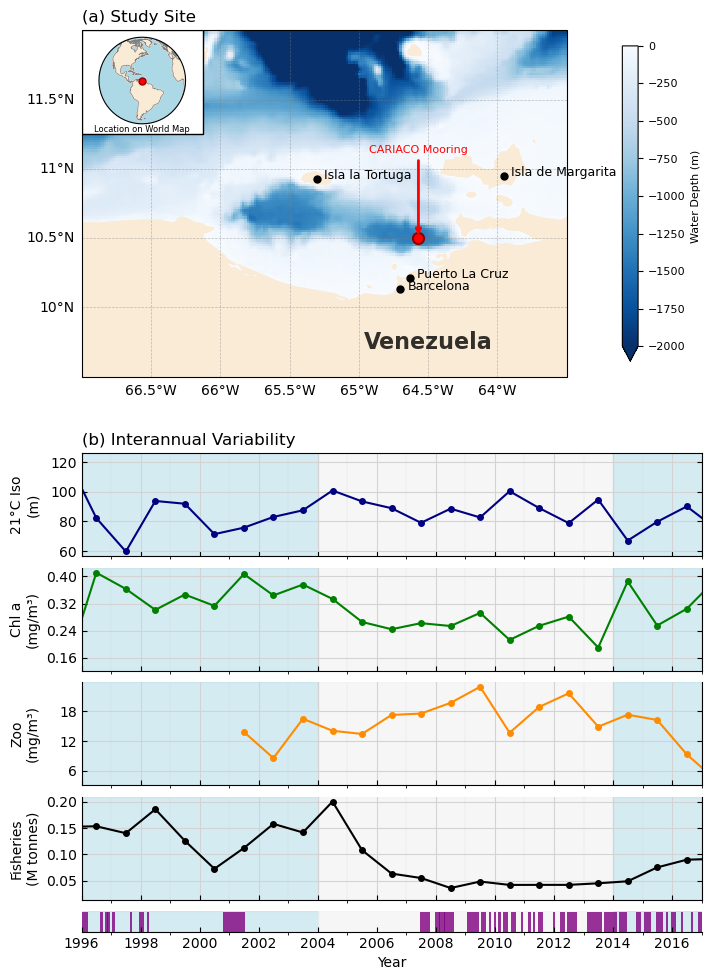

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
from scipy.stats import gmean
import datetime
import pygmt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# --- Helper Function 1: Geometric Mean Calculation ---
def safe_gmean(series):
    positive_values = series.dropna()
    positive_values = positive_values[positive_values > 0]
    if positive_values.empty:
        return np.nan
    return gmean(positive_values)

# --- Helper Function 2: Data Processing ---
def process_data_for_timelines(CARIACO_raw, Fish_raw):
    CARIACO_raw['date'] = pd.to_datetime(CARIACO_raw.time_month, format="%m-%Y")
    Fish_raw['date'] = pd.to_datetime(Fish_raw.year, format="%Y")
    CARIACO_raw['Zoo_Total'] = CARIACO_raw['Mesh200'] + CARIACO_raw['Mesh500']
    Fish_raw['sardinelandings_M'] = Fish_raw['sardinelandings'] / 1_000_000

    yearly_cariaco = CARIACO_raw.resample('YE', on='date').agg({
        'Isotherm_21': safe_gmean,
        'Chlorophyll': safe_gmean,
        'Zoo_Total': safe_gmean
    }).reset_index()

    yearly_cariaco['plot_date'] = yearly_cariaco['date'].dt.to_period('Y').dt.to_timestamp() + pd.DateOffset(months=6)
    Fish_raw['plot_date'] = Fish_raw['date'] + pd.DateOffset(months=6)
    
    c1_ranges = [
        (datetime.date(1996, 1, 1), datetime.date(2003, 12, 31)),
        (datetime.date(2014, 1, 1), datetime.date(2016, 12, 31))
    ]
    c2_ranges = [
        (datetime.date(2004, 1, 1), datetime.date(2013, 12, 31))
    ]
    
    return yearly_cariaco, Fish_raw, c1_ranges, c2_ranges

# --- Fixed Parameters for Map ---
lon_min, lon_max = -67.0, -63.5
lat_min, lat_max = 9.5, 12.0
region = [lon_min, lon_max, lat_min, lat_max] 
mooring_lon = -64.57
mooring_lat = 10.5

def load_bathymetry(region):
    grid = pygmt.datasets.load_earth_relief(resolution="01m", region=region)
    grid = pygmt.grdclip(grid, above=[0, 0]) 
    return grid

def draw_cariaco_map_with_inset(ax, fig, grid):
    cmap = plt.get_cmap("Blues_r")
    norm = mcolors.Normalize(vmin=-2000, vmax=0)

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    grid.plot.pcolormesh(ax=ax, cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0, add_colorbar=False)

    ax.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--', zorder=3)
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 10}; gl.ylabel_style = {'size': 10}
    gl.xformatter = LONGITUDE_FORMATTER; gl.yformatter = LATITUDE_FORMATTER

    cities = {'Puerto La Cruz': (-64.63, 10.21), 'Barcelona': (-64.70, 10.13)}
    islands = {'Isla de Margarita': (-63.95, 10.95), 'Isla la Tortuga': (-65.30, 10.93)}
    for label, (clon, clat) in {**cities, **islands}.items():
        ax.plot(clon, clat, 'o', color='black', markersize=5, transform=ccrs.PlateCarree(), zorder=5)
        ax.text(clon + 0.05, clat, label, fontsize=9, color='black', transform=ccrs.PlateCarree(), zorder=5)

    ax.text(-64.5, 9.7, 'Venezuela', fontsize=16, color='black', weight='bold', ha='center', alpha=0.8, transform=ccrs.PlateCarree(), zorder=5)
    ax.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=8, markeredgecolor='darkred', markeredgewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
    ax.annotate('CARIACO Mooring', xy=(mooring_lon, mooring_lat), xytext=(mooring_lon, mooring_lat + 0.6),
                fontsize=8, color='red', ha='center', va='bottom',
                arrowprops=dict(arrowstyle='-|>', color='red', lw=2, relpos=(0.5, 0.)),
                transform=ccrs.PlateCarree(), zorder=10)
    
    inset_x, inset_y, inset_w, inset_h_total = 0.0, 1.0 - 0.30, 0.25, 0.30
    rect_patch = mpatches.Rectangle((inset_x, inset_y), inset_w, inset_h_total, facecolor='white', edgecolor='black', linewidth=1.0, transform=ax.transAxes, zorder=11)
    ax.add_patch(rect_patch)
    map_h = inset_w; map_y = inset_y + (inset_h_total - map_h) - 0.02
    ax_inset = ax.inset_axes([inset_x, map_y, inset_w, map_h], projection=ccrs.Orthographic(central_longitude=mooring_lon, central_latitude=mooring_lat), zorder=12)
    ax_inset.set_global(); ax_inset.add_feature(cfeature.OCEAN, color='lightblue', zorder=0)
    ax_inset.add_feature(cfeature.LAND, color='antiquewhite', zorder=1)
    ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='grey', zorder=2)
    ax_inset.plot(mooring_lon, mooring_lat, 'o', color='red', markersize=5, markeredgecolor='darkred', markeredgewidth=1.0, transform=ccrs.PlateCarree(), zorder=13)
    ax.text(inset_x + inset_w / 2, inset_y + 0.0, "Location on World Map", ha='center', va='bottom', fontsize=6, transform=ax.transAxes, zorder=13)
            
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.7, pad=0.05, extend='min')
    cbar.set_label('Water Depth (m)', fontsize=8); cbar.ax.tick_params(labelsize=8)

# --- MAIN PLOTTING CODE ---
if 'date' not in CARIACO.columns:
    CARIACO['date'] = pd.to_datetime(CARIACO['time_month'], format="%m-%Y")

yearly_cariaco, Fish, c1_ranges, c2_ranges = process_data_for_timelines(CARIACO, Fish)
bathymetry_grid = load_bathymetry(region)

fig = plt.figure(figsize=(7, 10), constrained_layout=True)
gs_main = fig.add_gridspec(2, 1, height_ratios=[1, 1.2])

# Map
ax_map = fig.add_subplot(gs_main[0], projection=ccrs.PlateCarree())
draw_cariaco_map_with_inset(ax=ax_map, fig=fig, grid=bathymetry_grid)
ax_map.set_title("(a) Study Site", loc='left', fontsize=12) 

# Time Series
gs_timeseries = gs_main[1].subgridspec(5, 1, hspace=0, height_ratios=[1, 1, 1, 1, 0.2])
axA = fig.add_subplot(gs_timeseries[0, 0])
axB = fig.add_subplot(gs_timeseries[1, 0], sharex=axA)
axC = fig.add_subplot(gs_timeseries[2, 0], sharex=axA)
axD = fig.add_subplot(gs_timeseries[3, 0], sharex=axA)
axE = fig.add_subplot(gs_timeseries[4, 0], sharex=axA)
timeline_axes = [axA, axB, axC, axD, axE]

axA.set_title("(b) Interannual Variability", fontsize=12, loc='left')

shade_colors = {'Cluster 1': 'lightblue', 'Cluster 2': '#f0f0f0'}
for ax in timeline_axes:
    for start, end in c1_ranges: ax.axvspan(start, end, color=shade_colors['Cluster 1'], alpha=0.5, zorder=0)
    for start, end in c2_ranges: ax.axvspan(start, end, color=shade_colors['Cluster 2'], alpha=0.6, zorder=0)

axA.plot(yearly_cariaco.plot_date, yearly_cariaco.Isotherm_21, color='navy', lw=1.5, marker='o', ms=4)
axA.set_ylabel("21°C Iso\n(m)", fontsize=10)
axB.plot(yearly_cariaco.plot_date, yearly_cariaco.Chlorophyll, color='green', lw=1.5, marker='o', ms=4)
axB.set_ylabel("Chl a\n(mg/m³)", fontsize=10)
axC.plot(yearly_cariaco.plot_date, yearly_cariaco.Zoo_Total, color='darkorange', lw=1.5, marker='o', ms=4)
axC.set_ylabel("Zoo\n(mg/m³)", fontsize=10)
axD.plot(Fish.plot_date, Fish.sardinelandings_M, color='black', marker='o', ms=4, lw=1.5)
axD.set_ylabel("Fisheries\n(M tonnes)", fontsize=10)

# HPLC Panel
valid_hplc_dates = CARIACO.dropna(subset=['micro'])['date']
bar_width = 31
axE.bar(valid_hplc_dates, np.ones(len(valid_hplc_dates)), width=bar_width, color='purple', edgecolor='none', alpha=0.8)
axE.spines['top'].set_visible(False)
axE.spines['left'].set_visible(False)
axE.spines['right'].set_visible(False)
axE.set_xlabel("Year", fontsize=10)

# Styling Loop (FIXED)
plot_start = datetime.date(1996, 1, 1)
plot_end = datetime.date(2017, 1, 1)

for i, ax in enumerate(timeline_axes):
    # Only apply y-axis tick formatting to the standard plots
    if ax != axE:
        ax.grid(True, color='lightgrey', which='major')
        ax.grid(True, lw=0.2, color='lightgrey', which="minor")
        ax.get_yaxis().set_major_locator(MaxNLocator(nbins=4)) # This line was the culprit
    else:
        ax.grid(False)
        ax.set_yticks([]) # Force removal for axE
        ax.set_ylabel("")

    ax.get_xaxis().set_minor_locator(mdates.YearLocator())
    ax.tick_params(top=False, right=True, direction="in", labelsize=10)
    ax.set_xlim(plot_start, plot_end)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    
    if ax != axE:
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_xlabel("") 

# Clean up
axB.spines['top'].set_visible(False)
axC.spines['top'].set_visible(False)
axD.spines['top'].set_visible(False)
fig.align_ylabels(timeline_axes)

# Alignment
fig.canvas.draw()
ts_pos = axA.get_position()
current_map_pos = ax_map.get_position()
ax_map.set_position([ts_pos.x0, current_map_pos.y0, current_map_pos.width, current_map_pos.height])

plt.savefig("Figure1_MapTS.pdf")
plt.show()